In [1]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/playground-series-s6e2/sample_submission.csv
/kaggle/input/playground-series-s6e2/train.csv
/kaggle/input/playground-series-s6e2/test.csv


In [2]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv('/kaggle/input/playground-series-s6e2/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s6e2/test.csv')

In [4]:
train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [5]:
train.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [7]:
train.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [8]:
train.shape

(630000, 15)

In [9]:
test.shape

(270000, 14)

Target distribution
Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64


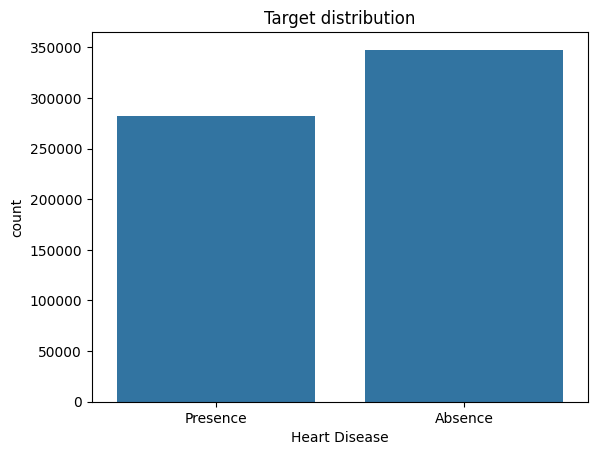

Target percentage
Heart Disease
Absence     55.166032
Presence    44.833968
Name: proportion, dtype: float64


In [10]:
print("Target distribution")
print(train['Heart Disease'].value_counts())

sns.countplot(x='Heart Disease', data=train)
plt.title("Target distribution")
plt.show()

print("Target percentage")
print(train['Heart Disease'].value_counts(normalize=True)*100)

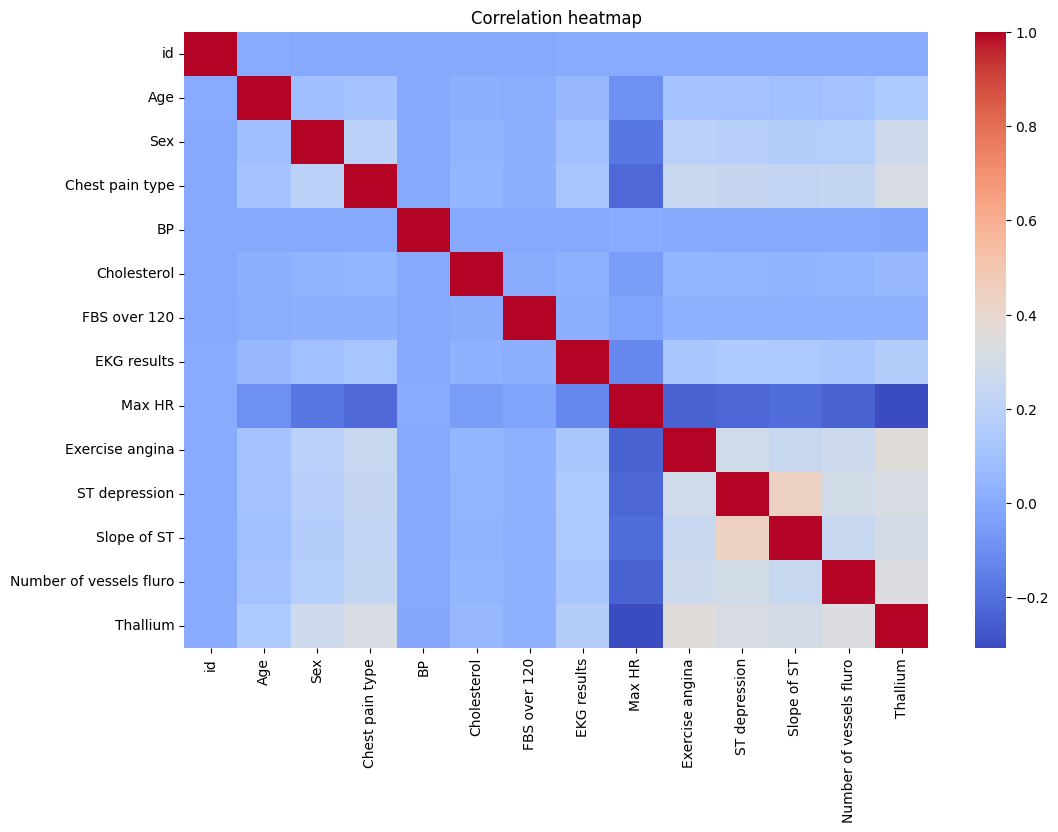

In [11]:
plt.figure(figsize=(12,8))
numeric_cols = train.select_dtypes(include=['int64','float64']).columns
sns.heatmap(train[numeric_cols].corr(), cmap='coolwarm', annot=False)
plt.title("Correlation heatmap")
plt.show()

In [12]:
train['Heart Disease'] = train['Heart Disease'].map({'Absence':0, 'Presence':1})
print(train['Heart Disease'].value_counts())

Heart Disease
0    347546
1    282454
Name: count, dtype: int64


In [13]:
ID_COL = 'id'
TARGET = 'Heart Disease'
X=train.drop([ID_COL, TARGET], axis=1)
y=train[TARGET]

X_test = test.drop([ID_COL], axis=1)

print(X.shape)
print(y.shape)
print(X_test.shape)

(630000, 13)
(630000,)
(270000, 13)


In [14]:
X.dtypes

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
dtype: object

Stratified K Fold

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

In [16]:
from sklearn.preprocessing import StandardScaler

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)
    
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(X_test_scaled)[:, 1] / 5
    
    print(f"Fold {fold+1} Done")

print("\nCV Log Loss:", log_loss(y, oof_preds))
print("CV ROC-AUC:", roc_auc_score(y, oof_preds))

Fold 1 Done
Fold 2 Done
Fold 3 Done
Fold 4 Done
Fold 5 Done

CV Log Loss: 0.28177921581344456
CV ROC-AUC: 0.9504884499160762


In [17]:
oof_xgb = np.zeros(len(X))
test_xgb = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = xgb.XGBClassifier(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
    )
    
    model.fit(X_train, y_train)
    
    oof_xgb[val_idx] = model.predict_proba(X_val)[:, 1]
    test_xgb += model.predict_proba(X_test)[:, 1] / 5
    
    print(f"Fold {fold+1} Done")

print("\nXGBoost CV Log Loss:", log_loss(y, oof_xgb))
print("XGBoost CV ROC-AUC:", roc_auc_score(y, oof_xgb))

Fold 1 Done
Fold 2 Done
Fold 3 Done
Fold 4 Done
Fold 5 Done

XGBoost CV Log Loss: 0.2681512984148644
XGBoost CV ROC-AUC: 0.9553137203689335


In [18]:
X.columns = X.columns.str.replace(" ", "_")
X_test.columns = X_test.columns.str.replace(" ", "_")

oof_lgb = np.zeros(len(X))
test_lgb = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1   
    )
    
    model.fit(X_train, y_train)
    
    oof_lgb[val_idx] = model.predict_proba(X_val)[:, 1]
    test_lgb += model.predict_proba(X_test)[:, 1] / 5

print("LightGBM CV Log Loss:", log_loss(y, oof_lgb))
print("LightGBM CV ROC-AUC:", roc_auc_score(y, oof_lgb))

LightGBM CV Log Loss: 0.2685851739377264
LightGBM CV ROC-AUC: 0.9552081266138049


In [19]:
oof_cat = np.zeros(len(X))
test_cat = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = CatBoostClassifier(
        iterations=800,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        random_seed=42,
        verbose=0   
    )
    
    model.fit(X_train, y_train)
    
    oof_cat[val_idx] = model.predict_proba(X_val)[:, 1]
    test_cat += model.predict_proba(X_test)[:, 1] / 5

print("CatBoost CV Log Loss:", log_loss(y, oof_cat))
print("CatBoost CV ROC-AUC:", roc_auc_score(y, oof_cat))

CatBoost CV Log Loss: 0.26775539851871877
CatBoost CV ROC-AUC: 0.955410832999707


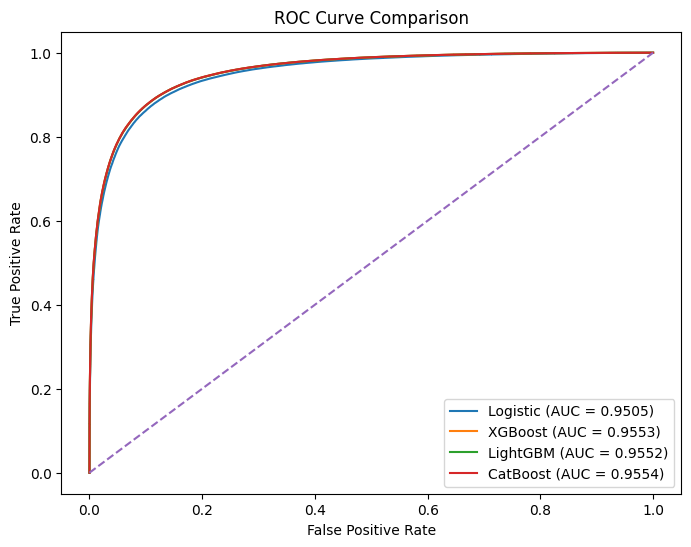

In [20]:
plt.figure(figsize=(8,6))

# Logistic
fpr_log, tpr_log, _ = roc_curve(y, oof_preds)
plt.plot(fpr_log, tpr_log, label=f'Logistic (AUC = {roc_auc_score(y, oof_preds):.4f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y, oof_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y, oof_xgb):.4f})')

# LightGBM
fpr_lgb, tpr_lgb, _ = roc_curve(y, oof_lgb)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {roc_auc_score(y, oof_lgb):.4f})')

# CatBoost
fpr_cat, tpr_cat, _ = roc_curve(y, oof_cat)
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {roc_auc_score(y, oof_cat):.4f})')

plt.plot([0,1], [0,1], linestyle='--')  # random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

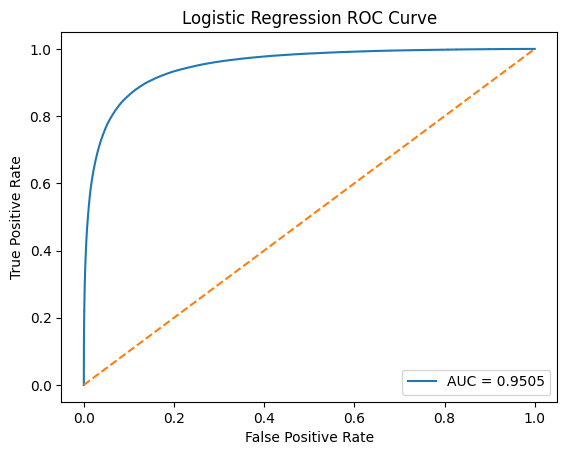

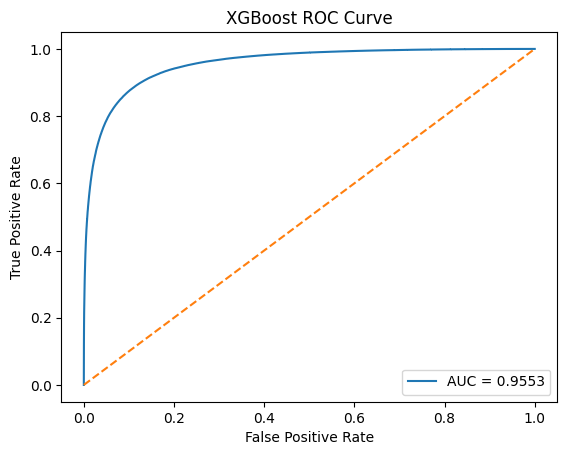

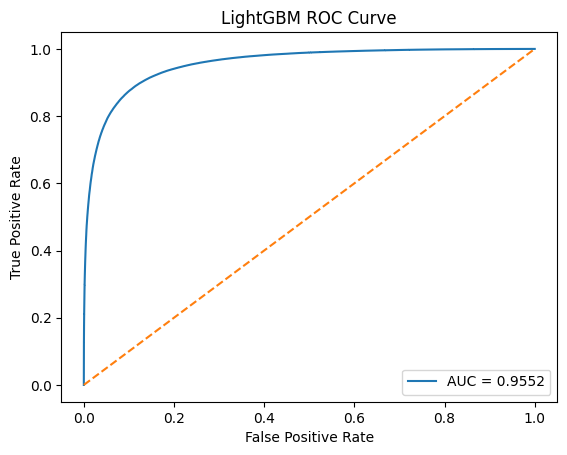

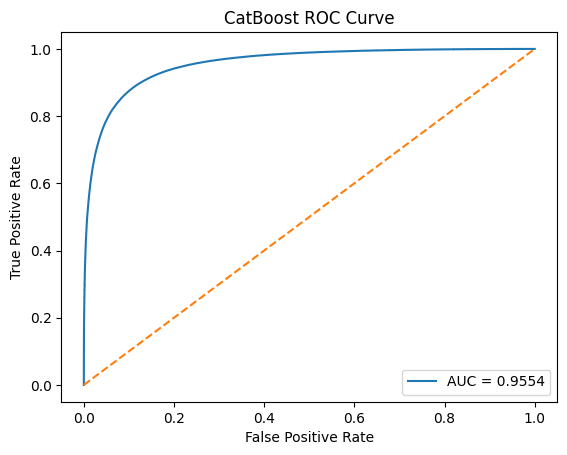

In [21]:
# Logistic Regression
plt.figure()
fpr, tpr, _ = roc_curve(y, oof_preds)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y, oof_preds):.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()


# XGBoost
plt.figure()
fpr, tpr, _ = roc_curve(y, oof_xgb)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y, oof_xgb):.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()


# LightGBM
plt.figure()
fpr, tpr, _ = roc_curve(y, oof_lgb)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y, oof_lgb):.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM ROC Curve")
plt.legend()
plt.show()


# CatBoost
plt.figure()
fpr, tpr, _ = roc_curve(y, oof_cat)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y, oof_cat):.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CatBoost ROC Curve")
plt.legend()
plt.show()


In [22]:
# Logistic
sub_log = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': test_preds
})
sub_log.to_csv("submission_logistic.csv", index=False)

# XGBoost
sub_xgb = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': test_xgb
})
sub_xgb.to_csv("submission_xgb.csv", index=False)

# LightGBM
sub_lgb = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': test_lgb
})
sub_lgb.to_csv("submission_lgb.csv", index=False)

# CatBoost
sub_cat = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': test_cat
})
sub_cat.to_csv("submission_cat.csv", index=False)
